In [256]:
# Importation des bibliothèques nécessaires pour les deux parties
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import copy
import time

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV



In [257]:
df = pd.read_csv("churn.xls") 

In [258]:
print("Shape :", df.shape)
display(df.head().T)

# Affichage des colonnes, types, valeurs manquantes et doublons
print("Colonnes :")
print(df.columns.tolist())

print("\nTypes des variables :")
display(df.dtypes.to_frame("dtype"))

print("\nValeurs manquantes :")
display(df.isnull().sum().to_frame("missing"))

print("\nDoublons exacts :", df.duplicated().sum())

Shape : (7043, 21)


,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


Colonnes :
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Types des variables :


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Valeurs manquantes :


,missing
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Doublons exacts : 0


In [259]:
# Variables numériques
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Variables catégorielles
cat_cols = df.select_dtypes(include="object").columns.tolist()

print("Variables numériques :")
print(num_cols)

print("\nNombre de variables numériques :", len(num_cols))

print("\nVariables catégorielles :")
print(cat_cols)

print("\nNombre de variables catégorielles :", len(cat_cols))

Variables numériques :
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Nombre de variables numériques : 3

Variables catégorielles :
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Nombre de variables catégorielles : 18


In [260]:
for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"Variable : {col}")
    print(f"Nombre de modalités : {df[col].nunique()}")
    print(df[col].unique())


Variable : customerID
Nombre de modalités : 7043
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

Variable : gender
Nombre de modalités : 2
['Female' 'Male']

Variable : Partner
Nombre de modalités : 2
['Yes' 'No']

Variable : Dependents
Nombre de modalités : 2
['No' 'Yes']

Variable : PhoneService
Nombre de modalités : 2
['No' 'Yes']

Variable : MultipleLines
Nombre de modalités : 3
['No phone service' 'No' 'Yes']

Variable : InternetService
Nombre de modalités : 3
['DSL' 'Fiber optic' 'No']

Variable : OnlineSecurity
Nombre de modalités : 3
['No' 'Yes' 'No internet service']

Variable : OnlineBackup
Nombre de modalités : 3
['Yes' 'No' 'No internet service']

Variable : DeviceProtection
Nombre de modalités : 3
['No' 'Yes' 'No internet service']

Variable : TechSupport
Nombre de modalités : 3
['No' 'Yes' 'No internet service']

Variable : StreamingTV
Nombre de modalités : 3
['No' 'Yes' 'No internet service']

Variable : StreamingMovies
Nombre de mo

In [261]:
display(df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [262]:
print("Nombre de clients par catégorie de Churn :")
display(df["Churn"].value_counts())

print("\nPourcentage :")
display(df["Churn"].value_counts(normalize=True).mul(100).round(2))

Nombre de clients par catégorie de Churn :


Churn
No     5174
Yes    1869
Name: count, dtype: int64


Pourcentage :


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

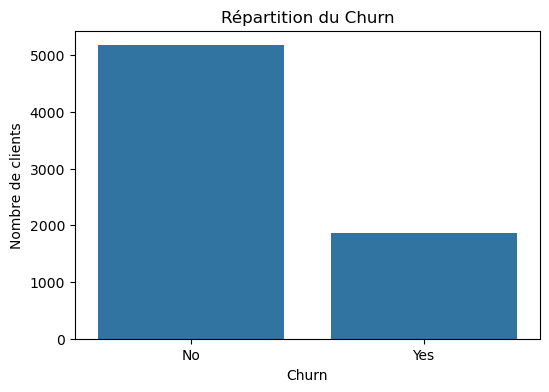

In [263]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Répartition du Churn")
plt.xlabel("Churn")
plt.ylabel("Nombre de clients")

plt.show()

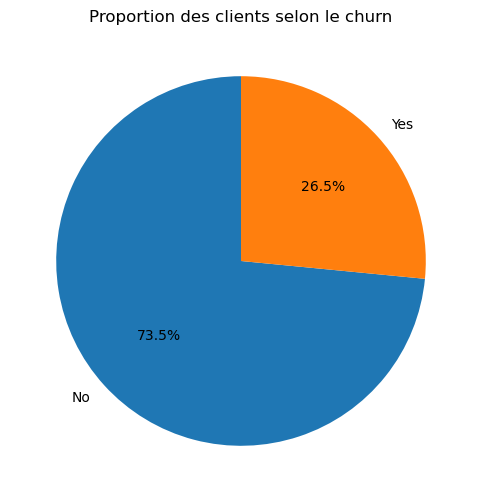

In [264]:
plt.figure(figsize=(6, 6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Proportion des clients selon le churn")
plt.ylabel("")

plt.show()

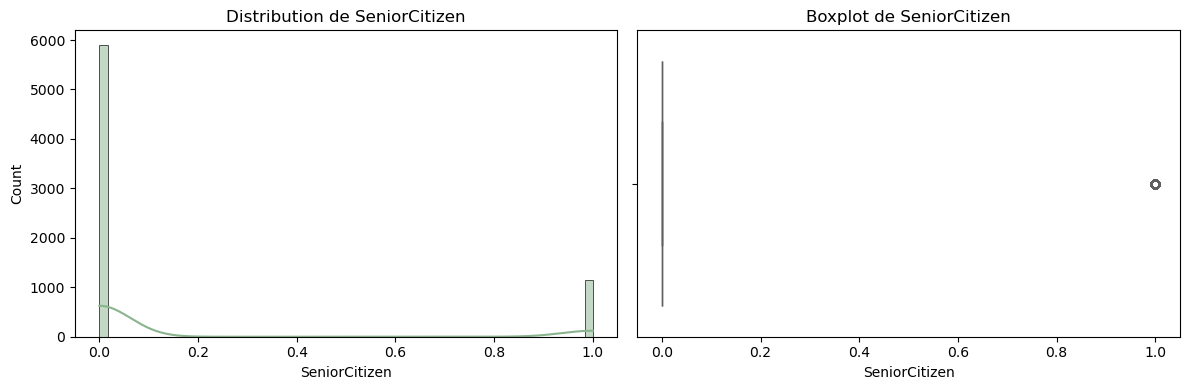

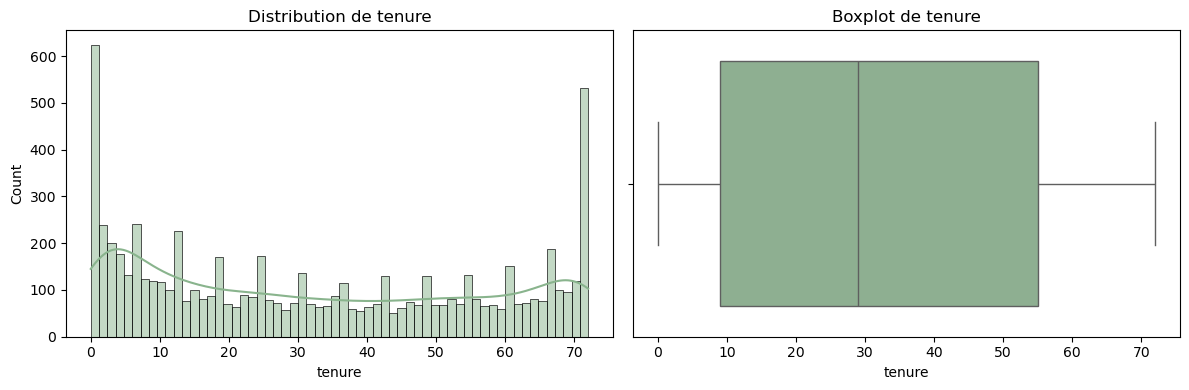

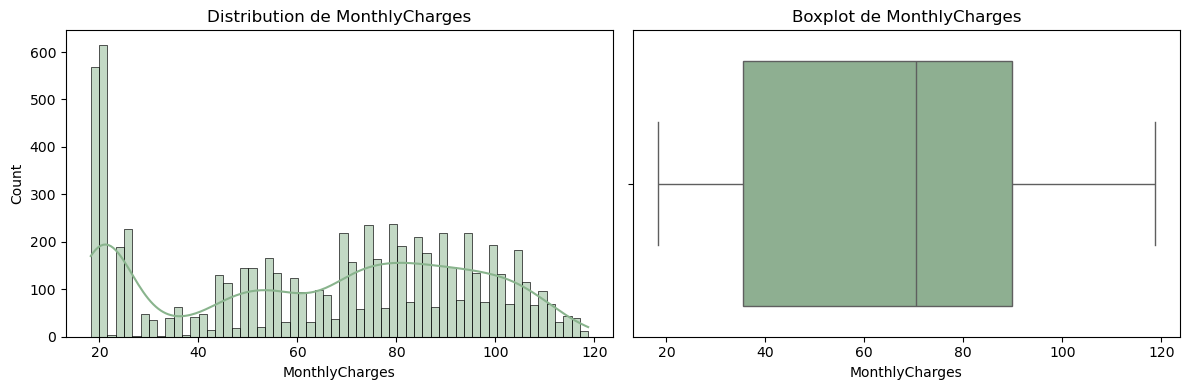

In [265]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], bins=60, kde=True, ax=axes[0], color="#89B48D")
    axes[0].set_title(f"Distribution de {col}")
    sns.boxplot(x=df[col], ax=axes[1], color="#89B48D")
    axes[1].set_title(f"Boxplot de {col}")
    plt.tight_layout()
    plt.show()

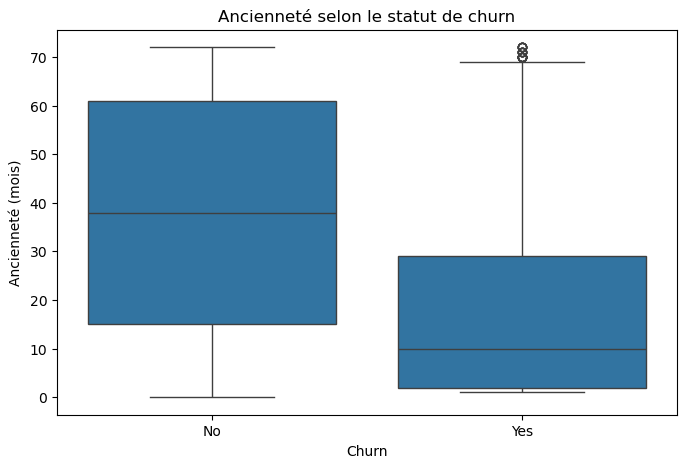

In [266]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Ancienneté selon le statut de churn")
plt.xlabel("Churn")
plt.ylabel("Ancienneté (mois)")

plt.show()

In [267]:

display(
    df.groupby("Churn")["tenure"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

,count,mean,median,std,min,max
Churn,,,,,,
No,5174,37.57,38.0,24.11,0,72
Yes,1869,17.98,10.0,19.53,1,72


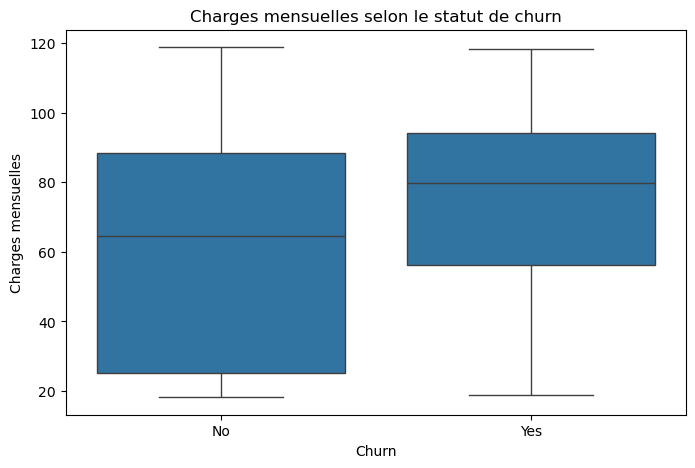

In [268]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Charges mensuelles selon le statut de churn")
plt.xlabel("Churn")
plt.ylabel("Charges mensuelles")

plt.show()

In [269]:
display(
    df.groupby("Churn")["MonthlyCharges"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

,count,mean,median,std,min,max
Churn,,,,,,
No,5174,61.27,64.43,31.09,18.25,118.75
Yes,1869,74.44,79.65,24.67,18.85,118.35


In [270]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(df["TotalCharges"].dtype)
print("Valeurs manquantes :", df["TotalCharges"].isna().sum())

float64
Valeurs manquantes : 11


In [271]:
display(
    df[df["TotalCharges"].isna()][
        ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
    ]
)

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [272]:
# Suppression des lignes avec TotalCharges manquant
df = df.dropna(subset=["TotalCharges"]).copy()

print("Nouvelle dimension :", df.shape)
print("Valeurs manquantes :")
display(df.isnull().sum())

Nouvelle dimension : (7032, 21)
Valeurs manquantes :


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

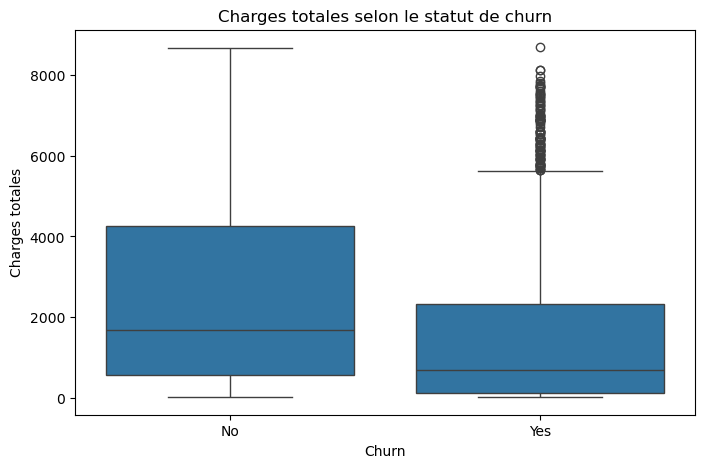

In [273]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Charges totales selon le statut de churn")
plt.xlabel("Churn")
plt.ylabel("Charges totales")

plt.show()

In [274]:
display(
    df.groupby('Churn')['TotalCharges']
    .agg(['count','mean','median','std','min','max'])
    .round(2)
)

,count,mean,median,std,min,max
Churn,,,,,,
No,5163,2555.34,1683.60,2329.46,18.80,8672.45
Yes,1869,1531.80,703.55,1890.82,18.85,8684.80


In [275]:
quant_cols = [
    'tenure', 'MonthlyCharges', 'TotalCharges'
]

In [276]:
from scipy.stats import mannwhitneyu

In [277]:
df["Churn_binary"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [278]:
for col in quant_cols:

    groupe_no = df.loc[df["Churn"] == "No", col]
    groupe_yes = df.loc[df["Churn"] == "Yes", col]

    statistic, p_value = mannwhitneyu(
        groupe_no,
        groupe_yes,
        alternative="two-sided"
    )

    print(f"{col}")
    print(f"Statistique U = {statistic:.2f}")
    print(f"p-value = {p_value:.400f}")
    print("-" * 40)

tenure
Statistique U = 7154668.00
p-value = 0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000006043046580882716746496424660589020011800178984183611404316231681525547261562969343635070519182270092728645244116018137950566112454604000360031023773914939568026946331781277298976088387120473
----------------------------------------
MonthlyCharges
Statistique U = 3663498.50
p-value = 0.0000000000000000000000000000000000000000000000000000084671950445487493748343478031170934356164829036218299462515834122278117472630315401985339213418101469342219060702821369454893042375757776507594343229357036761939525604248046875000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
----------------------------------------
TotalCharges
Sta

In [279]:
df.drop(columns=["Churn_binary"], inplace=True)

=== Tableau croisé ===
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1306   166
Two year        1637    48



=== Taux de churn ===
Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64

=== Test du Chi² ===
Chi² = 1179.5458287339445
p-value = 7.326182186265472e-257
dof = 2

=== V de Cramér ===
V de Cramér = 0.4095604189089921


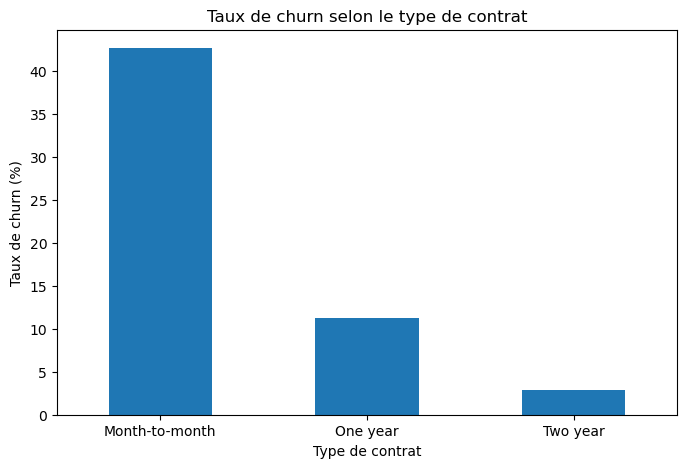

In [280]:
# Tableau croisé
Contract_contingency = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

print("=== Tableau croisé ===")
print(Contract_contingency)


# Taux de churn
churn_rate_contract = (
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print("\n=== Taux de churn ===")
print(churn_rate_contract)


# Test du Chi²
from scipy.stats import chi2_contingency
import numpy as np

chi2_contract, p_contract, dof_contract, expected_contract = chi2_contingency(
    Contract_contingency
)

print("\n=== Test du Chi² ===")
print("Chi² =", chi2_contract)
print("p-value =", p_contract)
print("dof =", dof_contract)


# V de Cramér
n = Contract_contingency.to_numpy().sum()
r, k = Contract_contingency.shape

cramers_v_contract = np.sqrt(
    (chi2_contract / n) / min(k - 1, r - 1)
)

print("\n=== V de Cramér ===")
print("V de Cramér =", cramers_v_contract)

plt.figure(figsize=(8, 5))

churn_rate_contract.plot(kind="bar")

plt.ylabel("Taux de churn (%)")
plt.xlabel("Type de contrat")
plt.title("Taux de churn selon le type de contrat")
plt.xticks(rotation=0)

plt.show()

=== Tableau croisé ===
Churn              No   Yes
InternetService            
DSL              1957   459
Fiber optic      1799  1297
No               1407   113

=== Taux de churn ===
InternetService
Fiber optic    41.892765
DSL            18.998344
No              7.434211
Name: Churn, dtype: float64

=== Test du Chi² ===
Chi² = 728.6956143058694
p-value = 5.831198962237274e-159
dof = 2

=== V de Cramér ===
V de Cramér = 0.3219093912684771


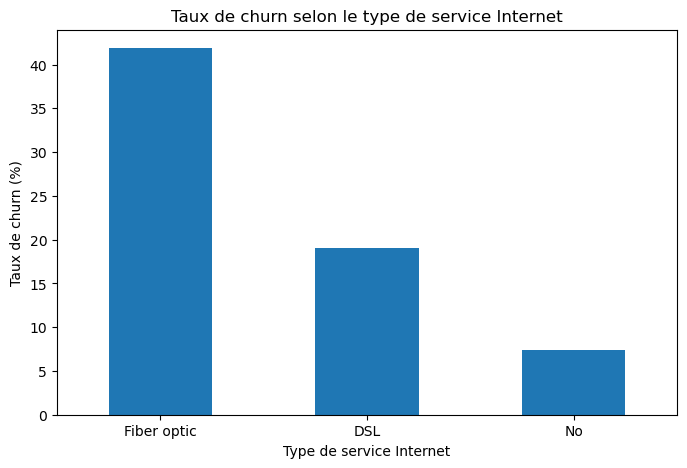

In [281]:
# Tableau croisé
InternetService_contingency = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

print("=== Tableau croisé ===")
print(InternetService_contingency)


# Taux de churn
churn_rate_internet_service = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print("\n=== Taux de churn ===")
print(churn_rate_internet_service)


# Test du Chi²
from scipy.stats import chi2_contingency
import numpy as np

chi2_internet_service, p_internet_service, dof_internet_service, expected_internet_service = chi2_contingency(
    InternetService_contingency
)

print("\n=== Test du Chi² ===")
print("Chi² =", chi2_internet_service)
print("p-value =", p_internet_service)
print("dof =", dof_internet_service)


# V de Cramér
n = InternetService_contingency.to_numpy().sum()
r, k = InternetService_contingency.shape

cramers_v_internet_service = np.sqrt(
    (chi2_internet_service / n) / min(k - 1, r - 1)
)

print("\n=== V de Cramér ===")
print("V de Cramér =", cramers_v_internet_service)

plt.figure(figsize=(8, 5))

churn_rate_internet_service.plot(kind="bar")

plt.ylabel("Taux de churn (%)")
plt.xlabel("Type de service Internet")
plt.title("Taux de churn selon le type de service Internet")
plt.xticks(rotation=0)

plt.show()

=== Tableau croisé ===
Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1284   258
Credit card (automatic)    1289   232
Electronic check           1294  1071
Mailed check               1296   308

=== Taux de churn ===
PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn, dtype: float64

=== Test du Chi² ===
Chi² = 645.4299001234638
p-value = 1.4263098511063342e-139
dof = 3

=== V de Cramér ===
V de Cramér = 0.30295987245491557


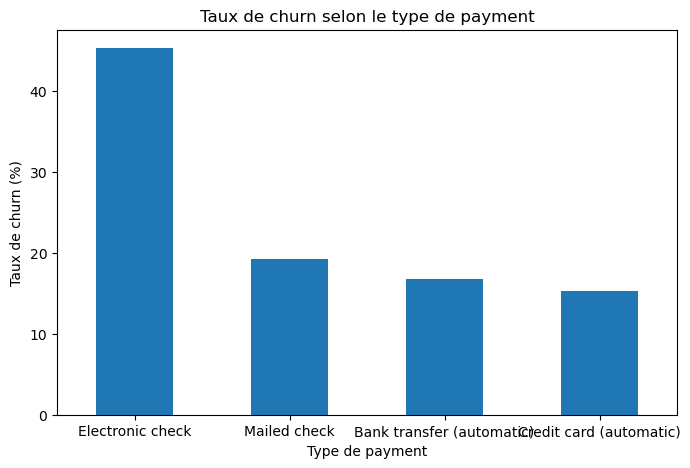

In [282]:
# Tableau croisé
Payment_contingency = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
)

print("=== Tableau croisé ===")
print(Payment_contingency)


# Taux de churn
churn_rate_payment = (
    df.groupby("PaymentMethod")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print("\n=== Taux de churn ===")
print(churn_rate_payment)


# Test du Chi²
from scipy.stats import chi2_contingency
import numpy as np

chi2_payment, p_payment, dof_payment, expected_payment = chi2_contingency(
    Payment_contingency
)

print("\n=== Test du Chi² ===")
print("Chi² =", chi2_payment)
print("p-value =", p_payment)
print("dof =", dof_payment)


# V de Cramér
n = Payment_contingency.to_numpy().sum()
r, k = Payment_contingency.shape

cramers_v_payment = np.sqrt(
    (chi2_payment / n) / min(k - 1, r - 1)
)

print("\n=== V de Cramér ===")
print("V de Cramér =", cramers_v_payment)

plt.figure(figsize=(8, 5))

churn_rate_payment.plot(kind="bar")

plt.ylabel("Taux de churn (%)")
plt.xlabel("Type de payment")
plt.title("Taux de churn selon le type de payment")
plt.xticks(rotation=0)

plt.show()

=== Tableau croisé ===
Churn                  No   Yes
TechSupport                    
No                   2026  1446
No internet service  1407   113
Yes                  1730   310

=== Taux de churn ===
TechSupport
No                     41.647465
Yes                    15.196078
No internet service     7.434211
Name: Churn, dtype: float64

=== Test du Chi² ===
Chi² = 824.925564387502
p-value = 7.407807748843711e-180
dof = 2

=== V de Cramér ===
V de Cramér = 0.342505815780552


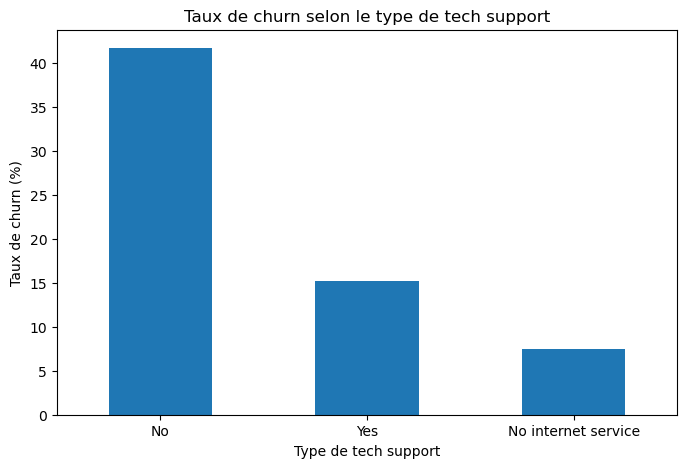

In [283]:
# Tableau croisé
techsupport_contingency = pd.crosstab(
    df["TechSupport"],
    df["Churn"]
)

print("=== Tableau croisé ===")
print(techsupport_contingency)


# Taux de churn
churn_rate_techsupport = (
    df.groupby("TechSupport")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print("\n=== Taux de churn ===")
print(churn_rate_techsupport)


# Test du Chi²
from scipy.stats import chi2_contingency
import numpy as np

chi2_techsupport, p_techsupport, dof_techsupport, expected_techsupport = chi2_contingency(
    techsupport_contingency
)

print("\n=== Test du Chi² ===")
print("Chi² =", chi2_techsupport)
print("p-value =", p_techsupport)
print("dof =", dof_techsupport)


# V de Cramér
n = techsupport_contingency.to_numpy().sum()
r, k = techsupport_contingency.shape

cramers_v_techsupport = np.sqrt(
    (chi2_techsupport / n) / min(k - 1, r - 1)
)

print("\n=== V de Cramér ===")
print("V de Cramér =", cramers_v_techsupport)

plt.figure(figsize=(8, 5))

churn_rate_techsupport.plot(kind="bar")

plt.ylabel("Taux de churn (%)")
plt.xlabel("Type de tech support")
plt.title("Taux de churn selon le type de tech support")
plt.xticks(rotation=0)

plt.show()

=== Tableau croisé ===
Churn                  No   Yes
OnlineSecurity                 
No                   2036  1461
No internet service  1407   113
Yes                  1720   295

=== Taux de churn ===
OnlineSecurity
No                     41.778667
Yes                    14.640199
No internet service     7.434211
Name: Churn, dtype: float64

=== Test du Chi² ===
Chi² = 846.6773889208487
p-value = 1.4006867477839222e-184
dof = 2

=== V de Cramér ===
V de Cramér = 0.3469920701082114


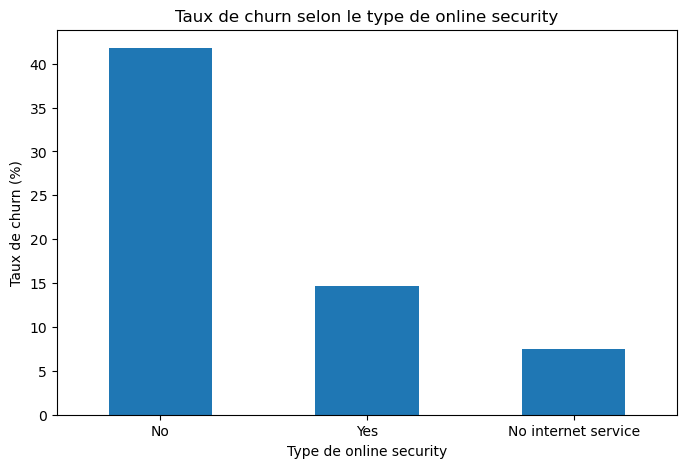

In [284]:
# Tableau croisé
onlinesecurity_contingency = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"]
)

print("=== Tableau croisé ===")
print(onlinesecurity_contingency)


# Taux de churn
churn_rate_onlinesecurity = (
    df.groupby("OnlineSecurity")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print("\n=== Taux de churn ===")
print(churn_rate_onlinesecurity)


# Test du Chi²
from scipy.stats import chi2_contingency
import numpy as np

chi2_onlinesecurity, p_onlinesecurity, dof_onlinesecurity, expected_onlinesecurity = chi2_contingency(
    onlinesecurity_contingency
)

print("\n=== Test du Chi² ===")
print("Chi² =", chi2_onlinesecurity)
print("p-value =", p_onlinesecurity)
print("dof =", dof_onlinesecurity)


# V de Cramér
n = onlinesecurity_contingency.to_numpy().sum()
r, k = onlinesecurity_contingency.shape

cramers_v_onlinesecurity = np.sqrt(
    (chi2_onlinesecurity / n) / min(k - 1, r - 1)
)

print("\n=== V de Cramér ===")
print("V de Cramér =", cramers_v_onlinesecurity)

plt.figure(figsize=(8, 5))

churn_rate_onlinesecurity.plot(kind="bar")

plt.ylabel("Taux de churn (%)")
plt.xlabel("Type de online security")
plt.title("Taux de churn selon le type de online security")
plt.xticks(rotation=0)

plt.show()

=== Tableau croisé ===
Churn                  No   Yes
OnlineBackup                   
No                   1854  1233
No internet service  1407   113
Yes                  1902   523

=== Taux de churn ===
OnlineBackup
No                     39.941691
Yes                    21.567010
No internet service     7.434211
Name: Churn, dtype: float64

=== Test du Chi² ===
Chi² = 599.1751847059026
p-value = 7.776099238804965e-131
dof = 2

=== V de Cramér ===
V de Cramér = 0.291902273936468


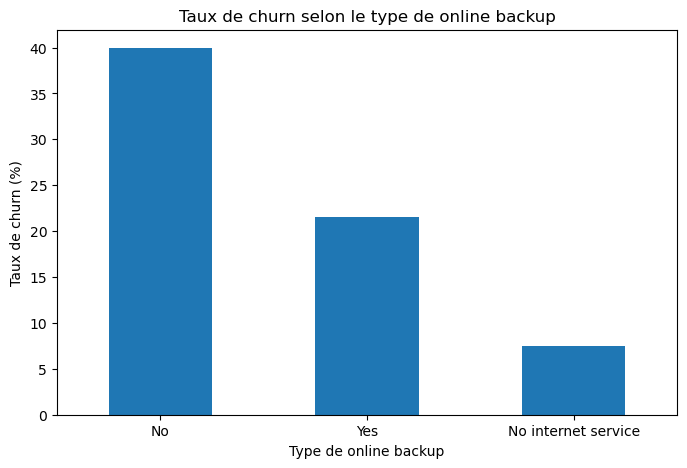

In [285]:
# Tableau croisé
onlinebackup_contingency = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"]
)

print("=== Tableau croisé ===")
print(onlinebackup_contingency)


# Taux de churn
churn_rate_onlinebackup = (
    df.groupby("OnlineBackup")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print("\n=== Taux de churn ===")
print(churn_rate_onlinebackup)


# Test du Chi²
from scipy.stats import chi2_contingency
import numpy as np

chi2_onlinebackup, p_onlinebackup, dof_onlinebackup, expected_onlinebackup = chi2_contingency(
    onlinebackup_contingency
)

print("\n=== Test du Chi² ===")
print("Chi² =", chi2_onlinebackup)
print("p-value =", p_onlinebackup)
print("dof =", dof_onlinebackup)


# V de Cramér
n = onlinebackup_contingency.to_numpy().sum()
r, k = onlinebackup_contingency.shape

cramers_v_onlinebackup = np.sqrt(
    (chi2_onlinebackup / n) / min(k - 1, r - 1)
)

print("\n=== V de Cramér ===")
print("V de Cramér =", cramers_v_onlinebackup)

plt.figure(figsize=(8, 5))

churn_rate_onlinebackup.plot(kind="bar")

plt.ylabel("Taux de churn (%)")
plt.xlabel("Type de online backup")
plt.title("Taux de churn selon le type de online backup")
plt.xticks(rotation=0)

plt.show()

=== Tableau croisé ===
Churn            No   Yes
SeniorCitizen            
0              4497  1393
1               666   476

=== Taux de churn ===
SeniorCitizen
1    41.681261
0    23.650255
Name: Churn, dtype: float64

=== Test du Chi² ===
Chi² = 158.4408162893713
p-value = 2.4792557203954705e-36
dof = 1

=== V de Cramér ===
V de Cramér = 0.15010463561752393


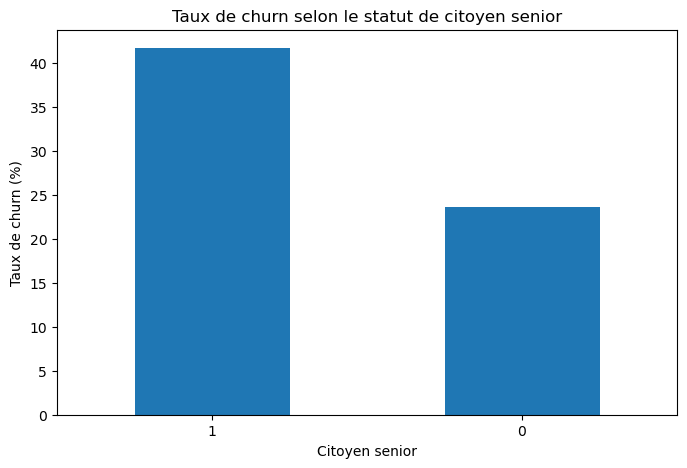

In [286]:
# Tableau croisé
senior_contingency = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"]
)

print("=== Tableau croisé ===")
print(senior_contingency)


# Taux de churn
churn_rate_senior = (
    df.groupby("SeniorCitizen")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print("\n=== Taux de churn ===")
print(churn_rate_senior)


# Test du Chi²
from scipy.stats import chi2_contingency
import numpy as np

chi2_senior, p_senior, dof_senior, expected_senior = chi2_contingency(
    senior_contingency
)

print("\n=== Test du Chi² ===")
print("Chi² =", chi2_senior)
print("p-value =", p_senior)
print("dof =", dof_senior)


# V de Cramér
n = senior_contingency.to_numpy().sum()
r, k = senior_contingency.shape

cramers_v_senior = np.sqrt(
    (chi2_senior / n) / min(k - 1, r - 1)
)

print("\n=== V de Cramér ===")
print("V de Cramér =", cramers_v_senior)

plt.figure(figsize=(8, 5))

churn_rate_senior.plot(kind="bar")

plt.ylabel("Taux de churn (%)")
plt.xlabel("Citoyen senior")
plt.title("Taux de churn selon le statut de citoyen senior")
plt.xticks(rotation=0)

plt.show()

In [287]:
# Tableau croisé
deviceprotection_contingency = pd.crosstab(
    df["DeviceProtection"],
    df["Churn"]
)

print("=== Tableau croisé ===")
print(deviceprotection_contingency)


# Taux de churn
churn_rate_deviceprotection = (
    df.groupby("DeviceProtection")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print("\n=== Taux de churn ===")
print(churn_rate_deviceprotection)


# Test du Chi²
from scipy.stats import chi2_contingency
import numpy as np

chi2_deviceprotection, p_deviceprotection, dof_deviceprotection, expected_deviceprotection = chi2_contingency(
    deviceprotection_contingency
)

print("\n=== Test du Chi² ===")
print("Chi² =", chi2_deviceprotection)
print("p-value =", p_deviceprotection)
print("dof =", dof_deviceprotection)


# V de Cramér
n = deviceprotection_contingency.to_numpy().sum()
r, k = deviceprotection_contingency.shape

cramers_v_deviceprotection = np.sqrt(
    (chi2_deviceprotection / n) / min(k - 1, r - 1)
)

print("\n=== V de Cramér ===")
print("V de Cramér =", cramers_v_deviceprotection)

plt.figure(figsize=(8, 5))

churn_rate_deviceprotection.plot(kind="bar")

plt.ylabel("Taux de churn (%)")
plt.xlabel("Protection appareil")
plt.title("Taux de churn selon le statut de protection appareil
")
plt.xticks(rotation=0)

plt.show()

SyntaxError: unterminated string literal (detected at line 53) (3008567775.py, line 53)

=== Tableau croisé ===
Churn               No  Yes
MultipleLines              
No                2536  849
No phone service   510  170
Yes               2117  850

=== Taux de churn ===
MultipleLines
Yes                 28.648466
No                  25.081241
No phone service    25.000000
Name: Churn, dtype: float64

=== Test du Chi² ===
Chi² = 11.271540824020612
p-value = 0.0035679273999811405
dof = 2

=== V de Cramér ===
V de Cramér = 0.040036141280711854


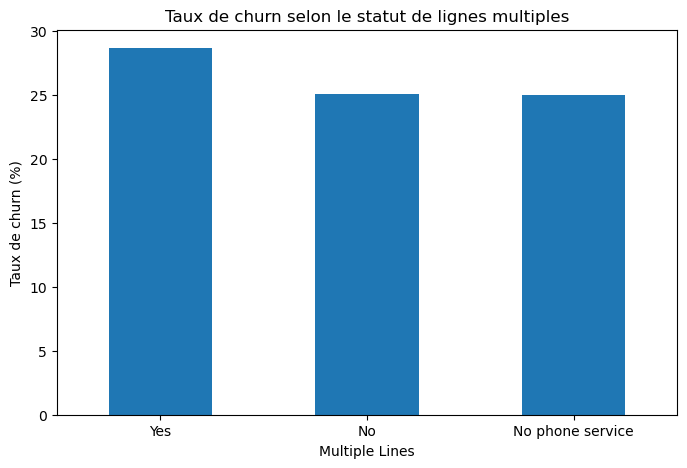

In [ ]:
# Tableau croisé
multipliens_contingency = pd.crosstab(
    df["MultipleLines"],
    df["Churn"]
)

print("=== Tableau croisé ===")
print(multipliens_contingency)


# Taux de churn
churn_rate_multipliens = (
    df.groupby("MultipleLines")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print("\n=== Taux de churn ===")
print(churn_rate_multipliens)


# Test du Chi²
from scipy.stats import chi2_contingency
import numpy as np

chi2_multipliens, p_multipliens, dof_multipliens, expected_multipliens = chi2_contingency(
    multipliens_contingency
)

print("\n=== Test du Chi² ===")
print("Chi² =", chi2_multipliens)
print("p-value =", p_multipliens)
print("dof =", dof_multipliens)


# V de Cramér
n = multipliens_contingency.to_numpy().sum()
r, k = multipliens_contingency.shape

cramers_v_multipliens = np.sqrt(
    (chi2_multipliens / n) / min(k - 1, r - 1)
)

print("\n=== V de Cramér ===")
print("V de Cramér =", cramers_v_multipliens)

plt.figure(figsize=(8, 5))

churn_rate_multipliens.plot(kind="bar")

plt.ylabel("Taux de churn (%)")
plt.xlabel("Multiple Lines")
plt.title("Taux de churn selon le statut de lignes multiples")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# Tableau croisé
Partner_contingency = pd.crosstab(
    df["Partner"],
    df["Churn"]
)

print("=== Tableau croisé ===")
print(Partner_contingency)


# Taux de churn
churn_rate_partner = (
    df.groupby("Partner")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print("\n=== Taux de churn ===")
print(churn_rate_partner)


# Test du Chi²
from scipy.stats import chi2_contingency
import numpy as np

chi2_partner, p_partner, dof_partner, expected_partner = chi2_contingency(
    Partner_contingency
)

print("\n=== Test du Chi² ===")
print("Chi² =", chi2_partner)
print("p-value =", p_partner)
print("dof =", dof_partner)


# V de Cramér
n = Partner_contingency.to_numpy().sum()
r, k = Partner_contingency.shape

cramers_v_partner = np.sqrt(
    (chi2_partner / n) / min(k - 1, r - 1)
)

print("\n=== V de Cramér ===")
print("V de Cramér =", cramers_v_partner)

=== Tableau croisé ===
Churn      No   Yes
Partner            
No       2439  1200
Yes      2724   669

=== Taux de churn ===
Partner
No     32.976092
Yes    19.717065
Name: Churn, dtype: float64

=== Test du Chi² ===
Chi² = 157.50315146557506
p-value = 3.97379757451591e-36
dof = 1

=== V de Cramér ===
V de Cramér = 0.1496598111790044


In [ ]:
# Tableau croisé
Dependents_contingency = pd.crosstab(
    df["Dependents"],
    df["Churn"]
)

print("=== Tableau croisé ===")
print(Dependents_contingency)


# Taux de churn
churn_rate_dependents = (
    df.groupby("Dependents")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print("\n=== Taux de churn ===")
print(churn_rate_dependents)


# Test du Chi²
from scipy.stats import chi2_contingency
import numpy as np

chi2_dependents, p_dependents, dof_dependents, expected_dependents = chi2_contingency(
    Dependents_contingency
)

print("\n=== Test du Chi² ===")
print("Chi² =", chi2_dependents)
print("p-value =", p_dependents)
print("dof =", dof_dependents)


# V de Cramér
n = Dependents_contingency.to_numpy().sum()
r, k = Dependents_contingency.shape

cramers_v_dependents = np.sqrt(
    (chi2_dependents / n) / min(k - 1, r - 1)
)

print("\n=== V de Cramér ===")
print("V de Cramér =", cramers_v_dependents)

=== Tableau croisé ===
Churn         No   Yes
Dependents            
No          3390  1543
Yes         1773   326

=== Taux de churn ===
Dependents
No     31.279140
Yes    15.531205
Name: Churn, dtype: float64

=== Test du Chi² ===
Chi² = 186.32163933855873
p-value = 2.0196592017051303e-42
dof = 1

=== V de Cramér ===
V de Cramér = 0.16277669159928557


In [ ]:
quant_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen"
]
quant_corr = df[quant_cols].corr()

In [ ]:
quant_corr

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
tenure,1.000000,0.246862,0.825880,0.015683
MonthlyCharges,0.246862,1.000000,0.651065,0.219874
TotalCharges,0.825880,0.651065,1.000000,0.102411
SeniorCitizen,0.015683,0.219874,0.102411,1.000000


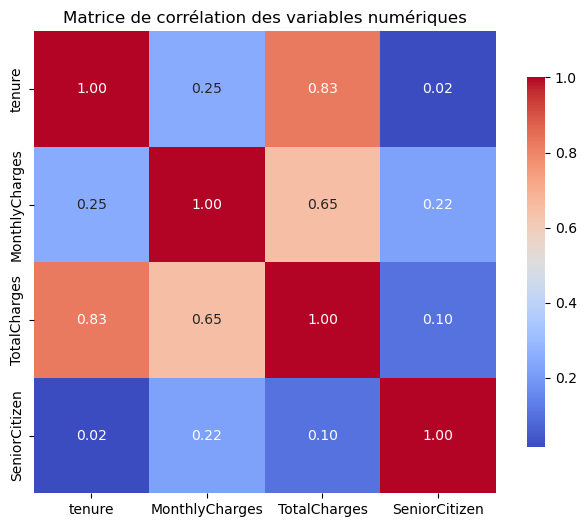

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    quant_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

In [ ]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [ ]:
if "customerID" in X.columns:
    X = X.drop(columns=["customerID"])

y = y.map({"No": 0, "Yes": 1})

print(X.shape , y.shape)
print(y.value_counts(normalize=True))

(7032, 19) (7032,)
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape, "| Test :", X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train : (5625, 19) | Test : (1407, 19)
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
    "PowerTransformer": PowerTransformer(method="yeo-johnson"),
    "NoScaling": "passthrough"
}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy", "precision": "precision",
    "recall": "recall", "f1": "f1", "roc_auc": "roc_auc"
}

scaler_model_results = []

for scaler_name, scaler in scalers.items():
    for model_name, model in models.items():

        preprocessor = ColumnTransformer(
            transformers=[
                ("num", scaler, numeric_features),
                ("bin", "passthrough", binary_features),
                ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_features)
            ]
        )

        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        scores = cross_validate(
            pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1
        )

        scaler_model_results.append({
            "Scaler": scaler_name,
            "Model": model_name,
            "Accuracy": scores["test_accuracy"].mean(),
            "Precision": scores["test_precision"].mean(),
            "Recall": scores["test_recall"].mean(),
            "F1-score": scores["test_f1"].mean(),
            "ROC-AUC": scores["test_roc_auc"].mean()
        })

       
scaler_model_df = pd.DataFrame(scaler_model_results)
display(scaler_model_df.sort_values("ROC-AUC", ascending=False).round(4))


StandardScaler + Logistic Regression → terminé
StandardScaler + KNN → terminé
StandardScaler + Decision Tree → terminé
StandardScaler + Random Forest → terminé
MinMaxScaler + Logistic Regression → terminé
MinMaxScaler + KNN → terminé
MinMaxScaler + Decision Tree → terminé
MinMaxScaler + Random Forest → terminé
RobustScaler + Logistic Regression → terminé
RobustScaler + KNN → terminé
RobustScaler + Decision Tree → terminé
RobustScaler + Random Forest → terminé
PowerTransformer + Logistic Regression → terminé
PowerTransformer + KNN → terminé
PowerTransformer + Decision Tree → terminé
PowerTransformer + Random Forest → terminé
NoScaling + Logistic Regression → terminé
NoScaling + KNN → terminé
NoScaling + Decision Tree → terminé
NoScaling + Random Forest → terminé


,Scaler,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
12,PowerTransformer,Logistic Regression,0.8043,0.6667,0.5284,0.5892,0.8507
0,StandardScaler,Logistic Regression,0.8025,0.6540,0.5465,0.5952,0.8460
16,NoScaling,Logistic Regression,0.8025,0.6541,0.5472,0.5957,0.8460
8,RobustScaler,Logistic Regression,0.8012,0.6525,0.5411,0.5914,0.8458
4,MinMaxScaler,Logistic Regression,0.8009,0.6519,0.5398,0.5904,0.8454
19,NoScaling,Random Forest,0.7925,0.6394,0.5030,0.5630,0.8275
7,MinMaxScaler,Random Forest,0.7916,0.6377,0.5003,0.5606,0.8269
11,RobustScaler,Random Forest,0.7916,0.6374,0.5010,0.5609,0.8269
15,PowerTransformer,Random Forest,0.7934,0.6419,0.5037,0.5644,0.8268
3,StandardScaler,Random Forest,0.7920,0.6390,0.4997,0.5607,0.8268


In [ ]:

preprocessor_final = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("bin", "passthrough", binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train_encoded = preprocessor_final.fit_transform(X_train)
X_test_encoded = preprocessor_final.transform(X_test)

print("Train encodé :", X_train_encoded.shape)
print("Test encodé  :", X_test_encoded.shape)


Train encodé : (5625, 45)
Test encodé  : (1407, 45)


In [297]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
cv_oof = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# 3. Logistic Regression
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# ------------------------------------------------------------
# 4. Prédictions OOF sur le TRAIN
# ------------------------------------------------------------

y_proba_oof = cross_val_predict(
    logistic_model,
    X_train_encoded,
    y_train,
    cv=cv_oof,
    method="predict_proba"
)[:, 1]


# ------------------------------------------------------------
# 5. Recherche du seuil optimal sur les prédictions OOF
# ------------------------------------------------------------

precisions, recalls, thresholds = precision_recall_curve(
    y_train,
    y_proba_oof
)

f1_scores = (
    2 * (precisions * recalls)
    / (precisions + recalls + 1e-9)
)

best_idx = np.argmax(f1_scores[:-1])

best_threshold_logistic = thresholds[best_idx]

# Prédictions OOF avec le seuil optimal
y_pred_logistic_oof = (
    y_proba_oof >= best_threshold_logistic
).astype(int)

print("\nSeuil optimal OOF :",
      round(best_threshold_logistic, 3))


# ------------------------------------------------------------
# 6. Entraînement du modèle final sur TOUT le TRAIN
# ------------------------------------------------------------

logistic_model.fit(
    X_train_encoded,
    y_train
)


# ------------------------------------------------------------
# 7. Probabilités sur le TEST
# ------------------------------------------------------------

y_proba_logistic = logistic_model.predict_proba(
    X_test_encoded
)[:, 1]


# ------------------------------------------------------------
# 8. Classification avec le seuil déterminé sur OOF
# ------------------------------------------------------------

y_pred_logistic_optimal = (
    y_proba_logistic >= best_threshold_logistic
).astype(int)


# ------------------------------------------------------------
# 9. Évaluation finale sur le TEST
# ------------------------------------------------------------

print("\n=== Logistic Regression (seuil optimal OOF) ===")

print("Seuil optimal :",
      round(best_threshold_logistic, 3))

print("Accuracy :",
      accuracy_score(
          y_test,
          y_pred_logistic_optimal
      ))

print("Precision:",
      precision_score(
          y_test,
          y_pred_logistic_optimal
      ))

print("Recall   :",
      recall_score(
          y_test,
          y_pred_logistic_optimal
      ))

print("F1-score :",
      f1_score(
          y_test,
          y_pred_logistic_optimal
      ))

print("ROC-AUC  :",
      roc_auc_score(
          y_test,
          y_proba_logistic
      ))


Seuil optimal OOF : 0.324

=== Logistic Regression (seuil optimal OOF) ===
Seuil optimal : 0.324
Accuracy : 0.7533759772565742
Precision: 0.5257142857142857
Recall   : 0.7379679144385026
F1-score : 0.6140155728587319
ROC-AUC  : 0.8362810670338715


In [301]:
# %%
# ============================================================
# 11. XGBOOST TUNÉ + SEUIL OPTIMAL AVEC OOF
# ============================================================

# ------------------------------------------------------------
# 1. Gestion du déséquilibre des classes
# ------------------------------------------------------------

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)


# ------------------------------------------------------------
# 2. Grille des hyperparamètres
# ------------------------------------------------------------

param_grid_xgb = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}


# ------------------------------------------------------------
# 3. Recherche des meilleurs hyperparamètres
# ------------------------------------------------------------

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_xgb,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# IMPORTANT : uniquement sur TRAIN
grid_xgb.fit(
    X_train_encoded,
    y_train
)


# Meilleur modèle
best_xgb = grid_xgb.best_estimator_


# ------------------------------------------------------------
# 4. Prédictions OOF sur TRAIN
# ------------------------------------------------------------

y_proba_xgb_oof = cross_val_predict(
    best_xgb,
    X_train_encoded,
    y_train,
    cv=cv_oof,
    method="predict_proba"
)[:, 1]


# ------------------------------------------------------------
# 5. Recherche du seuil optimal avec les OOF
# ------------------------------------------------------------

precisions_xgb, recalls_xgb, thresholds_xgb = (
    precision_recall_curve(
        y_train,
        y_proba_xgb_oof
    )
)

f1_xgb = (
    2 * (precisions_xgb * recalls_xgb)
    / (precisions_xgb + recalls_xgb + 1e-9)
)

best_idx_xgb = np.argmax(
    f1_xgb[:-1]
)

best_threshold_xgb = thresholds_xgb[
    best_idx_xgb
]

# Prédictions OOF avec le seuil optimal
y_pred_xgb_oof = (
    y_proba_xgb_oof >= best_threshold_xgb
).astype(int)

print("\nSeuil optimal XGBoost :",
      round(best_threshold_xgb, 3))


# ------------------------------------------------------------
# 6. Entraînement final du meilleur XGBoost sur tout TRAIN
# ------------------------------------------------------------

best_xgb.fit(
    X_train_encoded,
    y_train
)


# ------------------------------------------------------------
# 7. Probabilités sur TEST
# ------------------------------------------------------------

y_proba_xgb = best_xgb.predict_proba(
    X_test_encoded
)[:, 1]


# ------------------------------------------------------------
# 8. Prédictions avec le seuil déterminé par OOF
# ------------------------------------------------------------

y_pred_xgb_optimal = (
    y_proba_xgb >= best_threshold_xgb
).astype(int)


# ------------------------------------------------------------
# 9. Pour l'instant : PAS d'évaluation sur TEST
# ------------------------------------------------------------

print("\n=== XGBoost optimisé ===")

print("Meilleurs paramètres :",
      grid_xgb.best_params_)

print("Seuil optimal OOF :",
      round(best_threshold_xgb, 3))

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Seuil optimal XGBoost : 0.587

=== XGBoost optimisé ===
Meilleurs paramètres : {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Seuil optimal OOF : 0.587


In [303]:
# ------------------------------------------------------------
# 9. Résultats XGBoost sur TEST
# ------------------------------------------------------------

print("\n=== XGBoost (seuil optimal OOF) ===")

print("Meilleurs paramètres :",
      grid_xgb.best_params_)

print("Meilleur ROC-AUC CV :",
      round(grid_xgb.best_score_, 4))

print("Seuil optimal OOF :",
      round(best_threshold_xgb, 3))

print("Accuracy :",
      round(accuracy_score(
          y_test,
          y_pred_xgb_optimal
      ), 4))

print("Precision:",
      round(precision_score(
          y_test,
          y_pred_xgb_optimal
      ), 4))

print("Recall   :",
      round(recall_score(
          y_test,
          y_pred_xgb_optimal
      ), 4))

print("F1-score :",
      round(f1_score(
          y_test,
          y_pred_xgb_optimal
      ), 4))

print("ROC-AUC  :",
      round(roc_auc_score(
          y_test,
          y_proba_xgb
      ), 4))


=== XGBoost (seuil optimal OOF) ===
Meilleurs paramètres : {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Meilleur ROC-AUC CV : 0.8503
Seuil optimal OOF : 0.587
Accuracy : 0.7683
Precision: 0.5476
Recall   : 0.738
F1-score : 0.6287
ROC-AUC  : 0.8403


In [302]:
# %%
# ============================================================
# 12. RANDOM FOREST TUNÉ + SEUIL OPTIMAL OOF
# ============================================================

param_grid_rf = {
    "n_estimators": [200, 300],
    "max_depth": [5, 8, 10, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# Recherche des meilleurs hyperparamètres uniquement sur X_train
grid_rf.fit(X_train_encoded, y_train)

best_rf = grid_rf.best_estimator_


# ============================================================
# 12.1 PRÉDICTIONS OOF SUR LE TRAIN
# ============================================================

y_proba_rf_oof = cross_val_predict(
    best_rf,
    X_train_encoded,
    y_train,
    cv=cv_oof,
    method="predict_proba"
)[:, 1]


# ============================================================
# 12.2 RECHERCHE DU SEUIL OPTIMAL SUR LES PRÉDICTIONS OOF
# ============================================================

precisions_rf, recalls_rf, thresholds_rf = precision_recall_curve(
    y_train,
    y_proba_rf_oof
)

f1_rf = (
    2 * (precisions_rf * recalls_rf)
    / (precisions_rf + recalls_rf + 1e-9)
)

best_idx_rf = np.argmax(f1_rf[:-1])

best_threshold_rf = thresholds_rf[best_idx_rf]


# ============================================================
# 12.3 PRÉDICTIONS OOF AVEC LE SEUIL OPTIMAL
# ============================================================

y_pred_rf_oof = (
    y_proba_rf_oof >= best_threshold_rf
).astype(int)

# Prédictions OOF avec le seuil optimal
y_pred_rf_oof = (
    y_proba_rf_oof >= best_threshold_rf
).astype(int)

# ============================================================
# 12.4 RÉSULTATS OOF
# ============================================================

print("\n=== Random Forest (seuil optimal OOF) ===")

print(
    "Meilleurs paramètres :",
    grid_rf.best_params_
)

print(
    "Meilleur ROC-AUC CV :",
    round(grid_rf.best_score_, 4)
)

print(
    "Seuil optimal OOF :",
    round(best_threshold_rf, 3)
)

print(
    "Accuracy :",
    round(accuracy_score(y_train, y_pred_rf_oof), 4)
)

print(
    "Precision:",
    round(precision_score(y_train, y_pred_rf_oof), 4)
)

print(
    "Recall   :",
    round(recall_score(y_train, y_pred_rf_oof), 4)
)

print(
    "F1-score :",
    round(f1_score(y_train, y_pred_rf_oof), 4)
)

print(
    "ROC-AUC  :",
    round(roc_auc_score(y_train, y_proba_rf_oof), 4)
)


# ============================================================
# 12.5 RÉENTRAÎNEMENT DU MODÈLE FINAL SUR TOUT LE TRAIN
# ============================================================

best_rf.fit(
    X_train_encoded,
    y_train
)


# ============================================================
# 12.6 PRÉDICTIONS SUR LE TEST
# ============================================================

y_proba_rf = best_rf.predict_proba(
    X_test_encoded
)[:, 1]

y_pred_rf_optimal = (
    y_proba_rf >= best_threshold_rf
).astype(int)

Fitting 5 folds for each of 128 candidates, totalling 640 fits

=== Random Forest (seuil optimal OOF) ===
Meilleurs paramètres : {'class_weight': None, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 300}
Meilleur ROC-AUC CV : 0.8492
Seuil optimal OOF : 0.317
Accuracy : 0.773
Precision: 0.5533
Recall   : 0.7572
F1-score : 0.6394
ROC-AUC  : 0.8491


In [304]:
# %%
# ============================================================
# 13. STACKING (LR + XGB + RF) + SEUIL OPTIMAL OOF
# ============================================================

estimators = [
    (
        "logistic",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    ),
    (
        "xgb",
        best_xgb
    ),
    (
        "rf",
        best_rf
    )
]

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    n_jobs=-1
)


# ============================================================
# 13.1 PRÉDICTIONS OOF SUR LE TRAIN
# ============================================================

y_proba_stack_oof = cross_val_predict(
    stacking_model,
    X_train_encoded,
    y_train,
    cv=cv_oof,
    method="predict_proba"
)[:, 1]


# ============================================================
# 13.2 RECHERCHE DU SEUIL OPTIMAL SUR LES PRÉDICTIONS OOF
# ============================================================

precisions_st, recalls_st, thresholds_st = precision_recall_curve(
    y_train,
    y_proba_stack_oof
)

f1_st = (
    2 * (precisions_st * recalls_st)
    / (precisions_st + recalls_st + 1e-9)
)

best_idx_st = np.argmax(f1_st[:-1])

best_threshold_st = thresholds_st[best_idx_st]


# ============================================================
# 13.3 PRÉDICTIONS OOF AVEC LE SEUIL OPTIMAL
# ============================================================

y_pred_stack_oof = (
    y_proba_stack_oof >= best_threshold_st
).astype(int)


# ============================================================
# 13.4 RÉSULTATS OOF
# ============================================================

print("\n=== Stacking (seuil optimal OOF) ===")

print(
    "Seuil optimal OOF :",
    round(best_threshold_st, 3)
)

print(
    "Accuracy :",
    round(accuracy_score(y_train, y_pred_stack_oof), 4)
)

print(
    "Precision:",
    round(precision_score(y_train, y_pred_stack_oof), 4)
)

print(
    "Recall   :",
    round(recall_score(y_train, y_pred_stack_oof), 4)
)

print(
    "F1-score :",
    round(f1_score(y_train, y_pred_stack_oof), 4)
)

print(
    "ROC-AUC  :",
    round(roc_auc_score(y_train, y_proba_stack_oof), 4)
)


# ============================================================
# 13.5 ENTRAÎNEMENT FINAL DU STACKING SUR TOUT LE TRAIN
# ============================================================

stacking_model.fit(
    X_train_encoded,
    y_train
)


# ============================================================
# 13.6 PRÉDICTIONS SUR LE TEST
# ============================================================

y_proba_stack = stacking_model.predict_proba(
    X_test_encoded
)[:, 1]

y_pred_stack_optimal = (
    y_proba_stack >= best_threshold_st
).astype(int)


=== Stacking (seuil optimal OOF) ===
Seuil optimal OOF : 0.347
Accuracy : 0.7918
Precision: 0.5913
Recall   : 0.7017
F1-score : 0.6418
ROC-AUC  : 0.8506


In [305]:
# %%
# ============================================================
# 14. ÉVALUATION FINALE SUR LE JEU DE TEST
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# 14.1 LOGISTIC REGRESSION
# ------------------------------------------------------------

y_pred_logistic_test = (
    y_proba_logistic >= best_threshold_logistic
).astype(int)


# ------------------------------------------------------------
# 14.2 XGBOOST
# ------------------------------------------------------------

y_pred_xgb_test = (
    y_proba_xgb >= best_threshold_xgb
).astype(int)


# ------------------------------------------------------------
# 14.3 RANDOM FOREST
# ------------------------------------------------------------

y_pred_rf_test = (
    y_proba_rf >= best_threshold_rf
).astype(int)


# ------------------------------------------------------------
# 14.4 STACKING
# ------------------------------------------------------------

y_pred_stack_test = (
    y_proba_stack >= best_threshold_st
).astype(int)


# ============================================================
# 14.5 FONCTION D'ÉVALUATION
# ============================================================

def evaluate_model_test(name, y_test, y_proba, y_pred, threshold):

    return {
        "Modèle": name,
        "Seuil": round(threshold, 3),
        "Accuracy": round(
            accuracy_score(y_test, y_pred), 4
        ),
        "Precision": round(
            precision_score(y_test, y_pred), 4
        ),
        "Recall": round(
            recall_score(y_test, y_pred), 4
        ),
        "F1-score": round(
            f1_score(y_test, y_pred), 4
        ),
        "ROC-AUC": round(
            roc_auc_score(y_test, y_proba), 4
        )
    }


# ============================================================
# 14.6 ÉVALUATION DE TOUS LES MODÈLES
# ============================================================

results_test = []

results_test.append(
    evaluate_model_test(
        "Logistic Regression",
        y_test,
        y_proba_logistic,
        y_pred_logistic_test,
        best_threshold_logistic
    )
)

results_test.append(
    evaluate_model_test(
        "XGBoost",
        y_test,
        y_proba_xgb,
        y_pred_xgb_test,
        best_threshold_xgb
    )
)

results_test.append(
    evaluate_model_test(
        "Random Forest",
        y_test,
        y_proba_rf,
        y_pred_rf_test,
        best_threshold_rf
    )
)

results_test.append(
    evaluate_model_test(
        "Stacking",
        y_test,
        y_proba_stack,
        y_pred_stack_test,
        best_threshold_st
    )
)


# ============================================================
# 14.7 TABLEAU COMPARATIF FINAL — TEST
# ============================================================

results_test_df = pd.DataFrame(results_test)

print("\n============================================================")
print("       COMPARAISON FINALE DES MODÈLES — TEST")
print("============================================================")

display(results_test_df)


       COMPARAISON FINALE DES MODÈLES — TEST


,Modèle,Seuil,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.324,0.7534,0.5257,0.7380,0.6140,0.8363
1,XGBoost,0.587,0.7683,0.5476,0.7380,0.6287,0.8403
2,Random Forest,0.317,0.7569,0.5297,0.7620,0.6250,0.8383
3,Stacking,0.347,0.7740,0.5586,0.7139,0.6268,0.8403


In [306]:
# %%
# ============================================================
# 15. COMPARAISON DES MODÈLES — ENTRAÎNEMENT / OOF
# ============================================================

results_train = [

    {
        "Modèle": "Logistic Regression",
        "Seuil": round(best_threshold_logistic, 3),
        "Accuracy": round(
            accuracy_score(
                y_train,
                y_pred_logistic_oof
            ), 4
        ),
        "Precision": round(
            precision_score(
                y_train,
                y_pred_logistic_oof
            ), 4
        ),
        "Recall": round(
            recall_score(
                y_train,
                y_pred_logistic_oof
            ), 4
        ),
        "F1-score": round(
            f1_score(
                y_train,
                y_pred_logistic_oof
            ), 4
        ),
        "ROC-AUC": round(
            roc_auc_score(
                y_train,
                y_proba_oof
            ), 4
        )
    },

    {
        "Modèle": "XGBoost",
        "Seuil": round(best_threshold_xgb, 3),
        "Accuracy": round(
            accuracy_score(
                y_train,
                y_pred_xgb_oof
            ), 4
        ),
        "Precision": round(
            precision_score(
                y_train,
                y_pred_xgb_oof
            ), 4
        ),
        "Recall": round(
            recall_score(
                y_train,
                y_pred_xgb_oof
            ), 4
        ),
        "F1-score": round(
            f1_score(
                y_train,
                y_pred_xgb_oof
            ), 4
        ),
        "ROC-AUC": round(
            roc_auc_score(
                y_train,
                y_proba_xgb_oof
            ), 4
        )
    },

    {
        "Modèle": "Random Forest",
        "Seuil": round(best_threshold_rf, 3),
        "Accuracy": round(
            accuracy_score(
                y_train,
                y_pred_rf_oof
            ), 4
        ),
        "Precision": round(
            precision_score(
                y_train,
                y_pred_rf_oof
            ), 4
        ),
        "Recall": round(
            recall_score(
                y_train,
                y_pred_rf_oof
            ), 4
        ),
        "F1-score": round(
            f1_score(
                y_train,
                y_pred_rf_oof
            ), 4
        ),
        "ROC-AUC": round(
            roc_auc_score(
                y_train,
                y_proba_rf_oof
            ), 4
        )
    },

    {
        "Modèle": "Stacking",
        "Seuil": round(best_threshold_st, 3),
        "Accuracy": round(
            accuracy_score(
                y_train,
                y_pred_stack_oof
            ), 4
        ),
        "Precision": round(
            precision_score(
                y_train,
                y_pred_stack_oof
            ), 4
        ),
        "Recall": round(
            recall_score(
                y_train,
                y_pred_stack_oof
            ), 4
        ),
        "F1-score": round(
            f1_score(
                y_train,
                y_pred_stack_oof
            ), 4
        ),
        "ROC-AUC": round(
            roc_auc_score(
                y_train,
                y_proba_stack_oof
            ), 4
        )
    }
]

results_train_df = pd.DataFrame(results_train)

print("\n============================================================")
print("       COMPARAISON DES MODÈLES — OOF / TRAIN")
print("============================================================")

display(results_train_df)


       COMPARAISON DES MODÈLES — OOF / TRAIN


,Modèle,Seuil,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.324,0.7751,0.5573,0.7478,0.6387,0.8457
1,XGBoost,0.587,0.7851,0.5766,0.7204,0.6405,0.8498
2,Random Forest,0.317,0.7730,0.5533,0.7572,0.6394,0.8491
3,Stacking,0.347,0.7918,0.5913,0.7017,0.6418,0.8506


In [308]:
# %%
# ============================================================
# 14. ÉVALUATION FINALE SUR LE JEU DE TEST
# ============================================================

final_results = pd.DataFrame([

    {
        "Modèle": "Logistic Regression",
        "Seuil": round(best_threshold_logistic, 3),

        "Accuracy": round(
            accuracy_score(
                y_test,
                y_pred_logistic_optimal
            ), 4
        ),

        "Precision": round(
            precision_score(
                y_test,
                y_pred_logistic_optimal
            ), 4
        ),

        "Recall": round(
            recall_score(
                y_test,
                y_pred_logistic_optimal
            ), 4
        ),

        "F1-score": round(
            f1_score(
                y_test,
                y_pred_logistic_optimal
            ), 4
        ),

        "ROC-AUC": round(
            roc_auc_score(
                y_test,
                y_proba_logistic
            ), 4
        )
    },


    {
        "Modèle": "XGBoost",
        "Seuil": round(best_threshold_xgb, 3),

        "Accuracy": round(
            accuracy_score(
                y_test,
                y_pred_xgb_optimal
            ), 4
        ),

        "Precision": round(
            precision_score(
                y_test,
                y_pred_xgb_optimal
            ), 4
        ),

        "Recall": round(
            recall_score(
                y_test,
                y_pred_xgb_optimal
            ), 4
        ),

        "F1-score": round(
            f1_score(
                y_test,
                y_pred_xgb_optimal
            ), 4
        ),

        "ROC-AUC": round(
            roc_auc_score(
                y_test,
                y_proba_xgb
            ), 4
        )
    },


    {
        "Modèle": "Random Forest",
        "Seuil": round(best_threshold_rf, 3),

        "Accuracy": round(
            accuracy_score(
                y_test,
                y_pred_rf_optimal
            ), 4
        ),

        "Precision": round(
            precision_score(
                y_test,
                y_pred_rf_optimal
            ), 4
        ),

        "Recall": round(
            recall_score(
                y_test,
                y_pred_rf_optimal
            ), 4
        ),

        "F1-score": round(
            f1_score(
                y_test,
                y_pred_rf_optimal
            ), 4
        ),

        "ROC-AUC": round(
            roc_auc_score(
                y_test,
                y_proba_rf
            ), 4
        )
    },


    {
        "Modèle": "Stacking (LR + XGB + RF)",
        "Seuil": round(best_threshold_st, 3),

        "Accuracy": round(
            accuracy_score(
                y_test,
                y_pred_stack_optimal
            ), 4
        ),

        "Precision": round(
            precision_score(
                y_test,
                y_pred_stack_optimal
            ), 4
        ),

        "Recall": round(
            recall_score(
                y_test,
                y_pred_stack_optimal
            ), 4
        ),

        "F1-score": round(
            f1_score(
                y_test,
                y_pred_stack_optimal
            ), 4
        ),

        "ROC-AUC": round(
            roc_auc_score(
                y_test,
                y_proba_stack
            ), 4
        )
    }
])


# ============================================================
# AFFICHAGE DU TABLEAU FINAL
# ============================================================

print("\n============================================================")
print("          ÉVALUATION FINALE — JEU DE TEST")
print("============================================================")

display(
    final_results
    .sort_values("F1-score", ascending=False)
    .reset_index(drop=True)
)


          ÉVALUATION FINALE — JEU DE TEST


,Modèle,Seuil,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,0.587,0.7683,0.5476,0.7380,0.6287,0.8403
1,Stacking (LR + XGB + RF),0.347,0.7740,0.5586,0.7139,0.6268,0.8403
2,Random Forest,0.317,0.7569,0.5297,0.7620,0.6250,0.8383
3,Logistic Regression,0.324,0.7534,0.5257,0.7380,0.6140,0.8363


In [310]:
print("================================")
print("VARIABLES DU MODÈLE")
print("================================")

print("\nVariables numériques :")
print(numeric_features)

print("\nVariables binaires :")
print(binary_features)

print("\nVariables catégorielles :")
print(categorical_features)

VARIABLES DU MODÈLE

Variables numériques :
['tenure', 'MonthlyCharges', 'TotalCharges']

Variables binaires :
['SeniorCitizen']

Variables catégorielles :
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [309]:
import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(
    preprocessor_final,
    "model/preprocessor.pkl"
)

joblib.dump(
    best_xgb,
    "model/xgboost_churn.pkl"
)


joblib.dump(
    best_threshold_xgb,
    "model/threshold.pkl"
)

print(" Preprocessor sauvegardé")
print(" Modèle XGBoost sauvegardé")
print(" Seuil optimal sauvegardé")

 Preprocessor sauvegardé
 Modèle XGBoost sauvegardé
 Seuil optimal sauvegardé
